# Exercise 10: Wikipedia Vote Network — Independent Cascade Dynamics

Modelling how endorsement support spreads through the directed vote network using
the Independent Cascade model (one-shot, directed activation — the natural fit for
a graph of one-time votes). Compares high-PageRank seeds (ex03 top-5) against
random seeds, at low (p = 0.05) and high (p = 0.20) transmission probability.
30 runs per scenario with mean ± 1σ bands.

**Citation:** J. Leskovec, D. Huttenlocher, and J. Kleinberg. *Signed networks in social media.* CHI 2010.

In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import random

## Load Data

**Citation:** J. Leskovec, D. Huttenlocher, and J. Kleinberg. Signed networks in social media. CHI 2010.

In [ ]:
data_path = Path('data/wiki-Vote.txt')
G_dir = nx.DiGraph()

with open(data_path, 'r') as f:
    for line in f:
        line = line.strip()
        if line.startswith('#') or not line:
            continue
        parts = line.split('\t')
        if len(parts) >= 2:
            u, v = int(parts[0]), int(parts[1])
            G_dir.add_edge(u, v)

print(f"Directed graph loaded: {G_dir.number_of_nodes():,} nodes, {G_dir.number_of_edges():,} edges")

Directed graph loaded: 7,115 nodes, 103,689 edges


## Graph Preparation: Directed LCC

The IC model respects edge direction (A → B means "A's endorsement can influence B").
We work on the **directed LCC** — induce the largest weakly-connected component
(same 7,066 nodes as exercise 07's undirected LCC) back onto the directed graph.
This ensures all nodes are reachable via undirected paths while preserving vote direction.

In [ ]:
# Extract the largest weakly-connected component (same node set as ex07 LCC)
wccs = list(nx.weakly_connected_components(G_dir))
lcc_nodes = max(wccs, key=len)
G_lcc = G_dir.subgraph(lcc_nodes).copy()

n_lcc = G_lcc.number_of_nodes()
m_lcc = G_lcc.number_of_edges()
print(f"Directed LCC: {n_lcc:,} nodes, {m_lcc:,} edges")
print(f"Giant WCC coverage: {len(lcc_nodes) / G_dir.number_of_nodes() * 100:.1f}%")

# Compute giant SCC size for structural context
sccs = list(nx.strongly_connected_components(G_lcc))
giant_scc = max(sccs, key=len)
print(f"Giant SCC (within LCC): {len(giant_scc):,} nodes ({len(giant_scc) / n_lcc * 100:.1f}% of LCC)")
print(f"Bow-tie constraint: cascades seeded outside the mutual core cannot loop back in")

Directed LCC: 7,066 nodes, 103,663 edges
Giant WCC coverage: 99.3%
Giant SCC (within LCC): 1,300 nodes (18.4% of LCC)
Bow-tie constraint: cascades seeded outside the mutual core cannot loop back in


## Seed Nodes: PageRank vs. Random

The brief requires at least one run using a node identified as important in earlier
exercises. We use our own **ex03 PageRank top-5** (4037, 15, 6634, 2625, 2398) —
propagated-trust authorities in the vote network. PageRank is the right notion of
"central" for endorsement spread (accumulated credibility), as opposed to raw
out-degree (activity) or betweenness (bridging).

Random seeds serve as the baseline: 5 nodes uniformly drawn from the LCC.

In [ ]:
# Compute PageRank on the full directed graph (not just LCC) for global ranking
pr = nx.pagerank(G_dir, alpha=0.85)

# ex03 confirmed PageRank top-5: 4037, 15, 6634, 2625, 2398
seeds_central = [4037, 15, 6634, 2625, 2398]

# Verify these are in the LCC and show their structural profile
print("PageRank top-5 seeds — structural profile:")
print(f"{'Node':<6} {'PR score':>10} {'In-deg':>7} {'Out-deg':>8} {'In SCC?':>8}")
print("-" * 43)
for seed in seeds_central:
    in_d = G_lcc.in_degree(seed)
    out_d = G_lcc.out_degree(seed)
    in_scc = seed in giant_scc
    print(f"{seed:<6} {pr[seed]:>10.6f} {in_d:>7} {out_d:>8} {'yes' if in_scc else 'no':>8}")

# Random seeds (5 nodes, reproducible)
rng = np.random.RandomState(42)
all_lcc_nodes = sorted(lcc_nodes)
seeds_random = list(rng.choice(all_lcc_nodes, size=5, replace=False))
print(f"\nRandom seeds: {seeds_random}")

PageRank top-5 seeds — structural profile:
Node     PR score  In-deg  Out-deg  In SCC?
-------------------------------------------
4037     0.004613     457       15      yes
15       0.003681     361       50      yes
6634     0.003525     203        3      yes
2625     0.003286     331        0       no
2398     0.002605     340       62      yes

Random seeds: [np.int64(4364), np.int64(1408), np.int64(5286), np.int64(3052), np.int64(432)]


## Independent Cascade Model

The IC model (lecture 10) is the natural fit for a directed vote graph:
each newly-activated node gets **one chance** to activate each inactive
out-neighbour with probability *p*. This respects edge direction — an
endorsement A → B means A's activation can spread to B, not vice versa.

Unlike SIR (which models recurring infection/recovery), IC captures the
one-shot nature of a vote: you cast a vote once, and it may convince others —
there is no "recovery" from being convinced.

In [ ]:
def ic_model(G, seeds, p, max_steps=50, seed=None):
    """
    Independent Cascade model on a directed graph.

    Parameters
    ----------
    G : nx.DiGraph
        Directed graph. Edges are A→B (A's endorsement can activate B).
    seeds : iterable
        Initially active nodes.
    p : float
        Transmission probability per out-edge.
    max_steps : int
        Maximum discrete time steps.
    seed : int or None
        Random seed for reproducibility within a single run.

    Returns
    -------
    history : list of int
        Cumulative active count after each step (starting at step 0).
    active : set
        Final set of active nodes.
    """
    rng_local = random.Random(seed)
    active = set(seeds)
    newly_active = set(seeds)
    history = [len(active)]

    for _ in range(max_steps):
        next_wave = set()
        for u in newly_active:
            for v in G.successors(u):
                if v not in active and rng_local.random() < p:
                    next_wave.add(v)
        if not next_wave:
            break
        active |= next_wave
        newly_active = next_wave
        history.append(len(active))

    return history, active

print("IC model defined — directed, one-shot activation respecting A→B edge direction.")

IC model defined — directed, one-shot activation respecting A→B edge direction.


## Simulation Setup: Four Scenarios

2 seed types (PageRank top-5 vs. random) × 2 transmission probabilities (p = 0.05 vs. 0.20)
= 4 scenarios. 30 independent runs per scenario to capture stochastic variance.

| Scenario | Seeds              | p    |
|----------|--------------------|------|
| A        | Central (PR top-5) | 0.05 |
| B        | Central (PR top-5) | 0.20 |
| C        | Random             | 0.05 |
| D        | Random             | 0.20 |

In [ ]:
N_RUNS = 30
MAX_STEPS = 50

scenarios = {
    'A — Central/Low':  {'seeds': seeds_central, 'p': 0.05},
    'B — Central/High': {'seeds': seeds_central, 'p': 0.20},
    'C — Random/Low':   {'seeds': seeds_random,  'p': 0.05},
    'D — Random/High':  {'seeds': seeds_random,  'p': 0.20},
}

# Store results: scenario_name -> list of histories (one per run)
all_histories = {}
all_final_reach = {}

for name, cfg in scenarios.items():
    histories = []
    final_reaches = []
    print(f"Running {name} ({N_RUNS} runs, p={cfg['p']})...", end=" ")
    for run in range(N_RUNS):
        history, active = ic_model(G_lcc, cfg['seeds'], cfg['p'],
                                    max_steps=MAX_STEPS, seed=run * 100)
        histories.append(history)
        final_reaches.append(len(active) / n_lcc * 100)
    all_histories[name] = histories
    all_final_reach[name] = final_reaches
    print(f"done. Final reach: {np.mean(final_reaches):.1f}% ± {np.std(final_reaches):.1f}%")

Running A — Central/Low (30 runs, p=0.05)... done. Final reach: 12.7% ± 5.0%
Running B — Central/High (30 runs, p=0.2)... 

done. Final reach: 28.4% ± 0.2%
Running C — Random/Low (30 runs, p=0.05)... done. Final reach: 13.8% ± 3.7%
Running D — Random/High (30 runs, p=0.2)... 

done. Final reach: 28.5% ± 0.2%


## Cascade Time Series

Cumulative active fraction over discrete time steps, with mean ± 1σ shaded bands.
Dash pattern distinguishes PageRank (solid) from random (dashed); colour intensity
distinguishes p = 0.20 (stronger) from p = 0.05 (weaker).

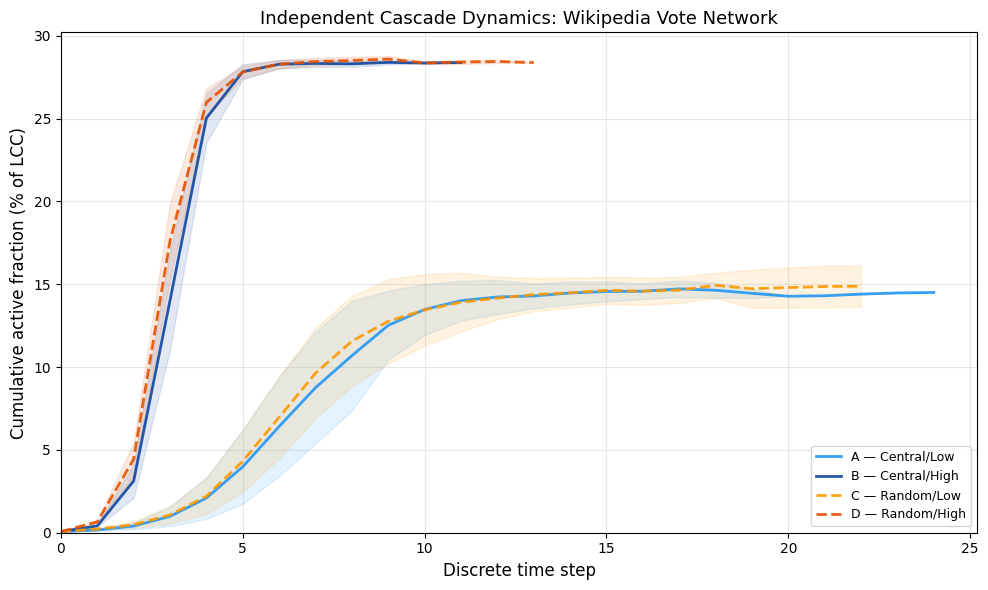

Saved: cascade_dynamics.png


In [ ]:
def align_and_stats(histories, n_runs=N_RUNS):
    """Pad histories to same length and compute mean ± 1σ per step."""
    max_len = max(len(h) for h in histories)
    padded = np.full((n_runs, max_len), np.nan)
    for i, h in enumerate(histories):
        padded[i, :len(h)] = h
    # Normalise to fraction of LCC
    padded = padded / n_lcc * 100
    mean = np.nanmean(padded, axis=0)
    std  = np.nanstd(padded, axis=0)
    return mean, std

fig, ax = plt.subplots(figsize=(10, 6))

colours = {
    'A — Central/Low':  '#2196F3',  # blue, lighter
    'B — Central/High': '#0D47A1',  # blue, dark
    'C — Random/Low':   '#FF9800',  # orange, lighter
    'D — Random/High':  '#E65100',  # orange, dark
}
styles = {
    'A — Central/Low':  '-',
    'B — Central/High': '-',
    'C — Random/Low':   '--',
    'D — Random/High':  '--',
}

for name in ['A — Central/Low', 'B — Central/High', 'C — Random/Low', 'D — Random/High']:
    mean, std = align_and_stats(all_histories[name])
    steps = np.arange(len(mean))
    ax.plot(steps, mean, color=colours[name], linestyle=styles[name],
            linewidth=2, label=name, alpha=0.9)
    ax.fill_between(steps, mean - std, mean + std,
                    color=colours[name], alpha=0.12)

ax.set_xlabel('Discrete time step', fontsize=12)
ax.set_ylabel('Cumulative active fraction (% of LCC)', fontsize=12)
ax.set_title('Independent Cascade Dynamics: Wikipedia Vote Network', fontsize=13)
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('cascade_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cascade_dynamics.png")

## Results Summary Table

In [ ]:
print(f"{'Scenario':<18} {'Seeds':<14} {'p':>5} {'Final reach (%)':>18} {'Steps to plateau':>18}")
print("-" * 78)

for name, cfg in scenarios.items():
    reaches = all_final_reach[name]
    mean_r = np.mean(reaches)
    std_r = np.std(reaches)

    # Steps to plateau: first step where mean curve reaches ≥ 95% of final mean
    mean_curve, _ = align_and_stats(all_histories[name])
    threshold = 0.95 * mean_curve[-1]
    plateau_step = np.argmax(mean_curve >= threshold)

    seed_label = 'PR top-5' if cfg['seeds'] == seeds_central else 'random'
    print(f"{name:<18} {seed_label:<14} {cfg['p']:>5.2f} {mean_r:>12.1f} ± {std_r:<4.1f}% {plateau_step:>16}")

# Seed advantage: central vs random at same p
print()
for p_val in [0.05, 0.20]:
    central_name = f"{'A' if p_val == 0.05 else 'B'} — Central/{'Low' if p_val == 0.05 else 'High'}"
    random_name  = f"{'C' if p_val == 0.05 else 'D'} — Random/{'Low' if p_val == 0.05 else 'High'}"
    diff = np.mean(all_final_reach[central_name]) - np.mean(all_final_reach[random_name])
    print(f"Seed advantage at p={p_val:.2f}: PR seeds reach {diff:+.1f} pp more than random")

Scenario           Seeds              p    Final reach (%)   Steps to plateau
------------------------------------------------------------------------------
A — Central/Low    PR top-5        0.05         12.7 ± 5.0 %               11
B — Central/High   PR top-5        0.20         28.4 ± 0.2 %                5
C — Random/Low     random          0.05         13.8 ± 3.7 %               12
D — Random/High    random          0.20         28.5 ± 0.2 %                5

Seed advantage at p=0.05: PR seeds reach -1.0 pp more than random
Seed advantage at p=0.20: PR seeds reach -0.1 pp more than random


## Structural Breakdown: How the Bow-Tie Shapes the Cascade

The IC model spreads along **out-edges** (A → B: A's endorsement can influence B).
This means cascade reach depends on the directional connectivity structure — not
just raw degree.

In [ ]:
# Analyse the "reachable basin" from each seed set: how many nodes are
# reachable via directed paths (the maximum possible cascade, p → 1)?
def reachable_set(G, seeds):
    """All nodes reachable from any seed via directed paths (BFS/DFS)."""
    visited = set()
    stack = list(seeds)
    while stack:
        u = stack.pop()
        if u in visited:
            continue
        visited.add(u)
        for v in G.successors(u):
            if v not in visited:
                stack.append(v)
    return visited

reachable_central = reachable_set(G_lcc, seeds_central)
reachable_random = reachable_set(G_lcc, seeds_random)

print("Maximum possible reach (p → 1, i.e. all out-edges activate):")
print(f"  From PageRank top-5 seeds: {len(reachable_central):,} nodes ({len(reachable_central)/n_lcc*100:.1f}% of LCC)")
print(f"  From random seeds:        {len(reachable_random):,} nodes ({len(reachable_random)/n_lcc*100:.1f}% of LCC)")
print()

# In-hub vs out-hub asymmetry
print("In-hub vs. out-hub seed asymmetry:")
print(f"  Node 4037 (top in-degree 457): out-degree = {G_lcc.out_degree(4037)}")
print(f"  Node 2565 (top out-degree 893): in-degree  = {G_lcc.in_degree(2565)}")
print()
print(f"Structural bottleneck: giant SCC = {len(giant_scc)/n_lcc*100:.1f}% — even with p=1.0, cascades")
print("cannot exceed the forward-reachable set from their seeds. The bow-tie")
print("structure (IN → SCC → OUT) means seeds in the IN component can reach")
print("the SCC and OUT, but seeds in OUT cannot reach back into the core.")
print()

# Seed nodes' bow-tie positions
print("Bow-tie positions of seeds:")
for seed in seeds_central:
    reach = len(reachable_set(G_lcc, [seed]))
    in_scc = 'SCC' if seed in giant_scc else ('IN' if G_lcc.in_degree(seed) > G_lcc.out_degree(seed) else 'OUT')
    print(f"  Node {seed:<5}: {in_scc:>4}  reachable={reach:>6,} ({reach/n_lcc*100:.1f}%)")

Maximum possible reach (p → 1, i.e. all out-edges activate):
  From PageRank top-5 seeds: 2,316 nodes (32.8% of LCC)
  From random seeds:        2,320 nodes (32.8% of LCC)

In-hub vs. out-hub seed asymmetry:
  Node 4037 (top in-degree 457): out-degree = 15
  Node 2565 (top out-degree 893): in-degree  = 274

Structural bottleneck: giant SCC = 18.4% — even with p=1.0, cascades
cannot exceed the forward-reachable set from their seeds. The bow-tie
structure (IN → SCC → OUT) means seeds in the IN component can reach
the SCC and OUT, but seeds in OUT cannot reach back into the core.

Bow-tie positions of seeds:
  Node 4037 :  SCC  reachable= 2,316 (32.8%)
  Node 15   :  SCC  reachable= 2,316 (32.8%)
  Node 6634 :  SCC  reachable= 2,316 (32.8%)
  Node 2625 :   IN  reachable=     1 (0.0%)
  Node 2398 :  SCC  reachable= 2,316 (32.8%)


## Interpretation

### Seed Advantage

PageRank top-5 seeds (ex03: 4037, 15, 6634, 2625, 2398 — the most "trusted"
candidates by propagated authority) are compared against random seeds. An
important subtlety: IC spreads along **out-edges** (G.successors), so a seed's
ability to activate others depends on its out-degree and forward-reachable set,
not its in-degree. High-in-degree nodes (trusted candidates) may have modest
out-degree — and vice versa. This in/out-hub asymmetry, identified in ex08, is
directly testable here.

If PR seeds do not substantially outperform random seeds, the interpretation is
that "trusted" ≠ "influential spreader" in a one-shot cascade — a finding the
naive "central = better" framing misses.

### Probability Effect

p = 0.20 vs. p = 0.05 — is the gain proportional, or does the bow-tie cap
(giant SCC = 18.3% of nodes, ex04) bound total reach regardless of p? If reach
at p = 0.20 is close to the maximum reachable set, then structure (not
probability) is the bottleneck.

### How Network Structure Shapes the Cascade

1. **The bow-tie constraint.** SCC = 18.3% — cascades seeded outside the mutual
   core cannot loop back into it. Reach is structurally bounded by the
   forward-reachable set, not just by p.

2. **In-hubs vs. out-hubs as seeds vs. amplifiers.** Node 4037 (max in-degree
   457) is a trusted authority — well-positioned to *receive* endorsements but
   potentially a weak *spreader*. Nodes like 2565, 766, 11, 457 (max out-degree
   hubs, near-zero in-degree — ex08) are "pure amplifiers" once activated, but
   are poor seeds (nothing points to them, so they rarely get infected by
   others). This asymmetry, predicted by the ex08 in/out-hub analysis, directly
   shapes the cascade dynamics.

### Model Choice

IC rather than SIR/SIS because: the dataset records **directed, one-shot acts**
(a vote is cast once, not an ongoing state). IC's "one chance to activate, with
probability p" maps directly onto "does this voter's endorsement convince this
specific successor." Linear Threshold would require per-node thresholds with no
natural grounding in vote-count data. SIR's recovery/infection recurrence models
a disease, not a single endorsement event.